# Triggered-detector exploration

Sanity check the v4 kernel labels before re-running the production pipeline.

Each layout strategy (grid, center, rings) draws random jitter / rotation, so the SAME strategy gives different positions for different RNG seeds. This notebook holds that variance up against shower variance: for several primaries, regenerate each strategy multiple times and look at how many detectors actually receive signal.

What's plotted:
1. Per (shower, strategy) → mean ± std triggered detector count over reinitializations.
2. Scatter of detector positions colored by deposited E, overlaid with the shower's transverse particle cloud, for representative pairs.
3. Histogram of trigger counts across every (shower, layout) sampled here.

In [1]:
import os, sys, math
_HERE = os.path.dirname(os.path.abspath('explore_trigger_counts.ipynb')) if '__file__' not in globals() else os.path.dirname(__file__)
if _HERE not in sys.path: sys.path.insert(0, _HERE)

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

import modules_v6
from modules_v6.constants import (
    SHOWER_CACHE, GEOMETRY_PATH, GEOMETRY_GROUP, DET_KEY,
    EAST_ENTRY, LAYER_EAST_DX, N_PLANES, NUM_SHOWERS, N_DETECTORS,
    LOG_E_MIN, LOG_E_MAX,
)
from modules_v6.fnn_surrogate import compute_labels_batch
from modules_v6.detector_strategies import _STRATEGIES, _STRATEGY_FNS
from modules_v4.tr_geometry    import load_tr_mountain
from modules_v4.tr_surface_map import SurfaceEastMap
import showerdata

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LAYOUT_THRESHOLD = 5e-2  # matches 04_optimize.py's reconstructability threshold

mountain = load_tr_mountain(GEOMETRY_PATH, GEOMETRY_GROUP, DET_KEY,
                            east_entry=EAST_ENTRY, layer_east_dx=LAYER_EAST_DX, n_planes=N_PLANES)
surface  = SurfaceEastMap.from_mountain(mountain, grid_h=256, grid_w=256).to(DEVICE)
print(f'mountain  N=[{mountain.n_min:.0f}, {mountain.n_max:.0f}]  Up=[{mountain.u_min:.0f}, {mountain.u_max:.0f}]')

data = showerdata.load(os.path.join(SHOWER_CACHE, f'cashed_showers_{NUM_SHOWERS}.pt'))
points = torch.as_tensor(data.points,     dtype=torch.float32)
dirs   = torch.as_tensor(data.directions, dtype=torch.float32)
energs = torch.as_tensor(data.energies,   dtype=torch.float32).reshape(-1)
pdg    = torch.as_tensor(data.pdg,        dtype=torch.long)
print(f'shower corpus: {points.shape}  E range {float(energs.min()):.2e}..{float(energs.max()):.2e}')

# Global recentering — mirrors 01_build_dataset.py when TAMBO_RECENTER_SHOWERS=1.
# Each shower's energetic particles get shifted so the energy-weighted xy
# centroid lands on the mountain bbox center. Without this, ~77% of cache
# showers don't overlap the mountain at all and produce all-zero labels.
# Toggle RECENTER off to inspect the raw cache distribution.
RECENTER = True
if RECENTER:
    mtn_cx = 0.5 * (mountain.n_min + mountain.n_max)
    mtn_cy = 0.5 * (mountain.u_min + mountain.u_max)
    mask    = (points[:, :, 3] > 0).float()
    w_sum   = mask.sum(dim=1).clamp(min=1.0)
    cx = (points[:, :, 0] * mask).sum(dim=1) / w_sum
    cy = (points[:, :, 1] * mask).sum(dim=1) / w_sum
    dx = (mtn_cx - cx).view(-1, 1)
    dy = (mtn_cy - cy).view(-1, 1)
    points = points.clone()
    points[..., 0] = points[..., 0] + dx * mask
    points[..., 1] = points[..., 1] + dy * mask
    print(f'[recenter] shifted clouds to mountain center ({mtn_cx:.1f}, {mtn_cy:.1f}); '
          f'per-shower dx in [{float(dx.min()):.0f}, {float(dx.max()):.0f}]  '
          f'dy in [{float(dy.min()):.0f}, {float(dy.max()):.0f}]')


mountain  N=[-2497, 2474]  Up=[2442, 3886]
shower corpus: torch.Size([50, 2048, 5])  E range 1.05e+05..9.56e+07
[recenter] shifted clouds to mountain center (-11.5, 3164.3); per-shower dx in [-9365, 7768]  dy in [-2756, 10762]


## Pick a diverse set of showers

We want primaries spanning energy and zenith. The kernel only lights up detectors if the shower's transverse cloud actually overlaps the mountain bbox — many random showers fail this trivially, so we screen on a default-grid layout first and keep ones with > 0 triggered detectors.

In [2]:
# Default grid (one reasonable layout) to screen showers for non-trivial overlap.
rng_scan = np.random.default_rng(42)
fn_grid  = _STRATEGY_FNS['layout_grid']
x_scan, y_scan = fn_grid(mountain, n_det=N_DETECTORS, rng=rng_scan, jitter_sigma=200.0)
x_scan = x_scan.float().to(DEVICE); y_scan = y_scan.float().to(DEVICE)

# Scan 2000 random cache entries, record trigger count
N = points.shape[0]
rng2 = np.random.default_rng(0)
scan_idxs = rng2.choice(N, size=20, replace=False)
scan_records = []
for s in scan_idxs:
    s = int(s)
    E, _ = compute_labels_batch(points[s:s+1].to(DEVICE), x_scan, y_scan, surface)
    n_trig = int((E[0] > LAYOUT_THRESHOLD).sum().item())
    if n_trig == 0:
        continue
    theta = float(torch.arccos(dirs[s, 2].clamp(-1.0, 1.0)).item())
    scan_records.append(dict(
        shower=s, E=float(energs[s].item()),
        theta_deg=math.degrees(theta),
        n_trig=n_trig,
    ))
df_scan = pd.DataFrame(scan_records)
print(f'{len(df_scan)}/{len(scan_idxs)} screened showers triggered >= 1 detector on the default grid')
df_scan.describe()[['E', 'theta_deg', 'n_trig']]

20/20 screened showers triggered >= 1 detector on the default grid


,E,theta_deg,n_trig
count,2.000000e+01,20.000000,20.00000
mean,1.854105e+07,81.565410,22.30000
std,2.918715e+07,10.818504,5.12065
min,1.053418e+05,61.493689,12.00000
25%,4.852884e+05,75.848330,18.75000
50%,1.466110e+06,83.942687,23.00000
75%,2.605078e+07,90.925246,25.00000
max,9.563493e+07,96.193338,34.00000


In [3]:
# Pick 6 showers spanning E and theta. Quartile-stratified sampling: low/mid/high E x more-vertical/more-horizontal.
df_scan['logE'] = np.log10(df_scan['E'])
df_scan['E_bin']     = pd.qcut(df_scan['logE'],   q=3, labels=['Elow', 'Emid', 'Ehigh'])
df_scan['theta_bin'] = pd.qcut(df_scan['theta_deg'], q=2, labels=['vert', 'horiz'])

rng_pick = np.random.default_rng(7)
selected = []
for E_b in ['Elow', 'Emid', 'Ehigh']:
    for th_b in ['vert', 'horiz']:
        sub = df_scan[(df_scan['E_bin']==E_b) & (df_scan['theta_bin']==th_b)]
        if not len(sub): continue
        pick = sub.iloc[int(rng_pick.integers(len(sub)))]
        selected.append(dict(shower=int(pick['shower']),
                             E=float(pick['E']),
                             theta_deg=float(pick['theta_deg']),
                             n_trig_default=int(pick['n_trig']),
                             tag=f'{E_b}/{th_b}'))
df_show = pd.DataFrame(selected)
df_show

,shower,E,theta_deg,n_trig_default,tag
0,2,2.585800e+05,64.815087,22,Elow/vert
1,0,3.565971e+05,93.444337,17,Elow/horiz
2,21,1.077874e+06,66.119195,16,Emid/vert
3,47,8.014558e+05,96.193338,23,Emid/horiz
4,16,2.059318e+07,73.171202,25,Ehigh/vert
5,6,2.906891e+07,85.377809,21,Ehigh/horiz


## For each shower × strategy, reinitialize N_SEEDS times

We regenerate each layout with a fresh RNG so jitter / ring rotation differ between samples. Trigger count is the number of detectors with E > `LAYOUT_THRESHOLD` (= 0.05, matches the optimization's reconstructability gate).

In [4]:
N_SEEDS = 25  # reinitializations per (shower, strategy)
records = []
layouts_cache = {}  # (shower, strategy, seed) -> (E (n_det,), x_det, y_det)  for plotting later

for _, row in df_show.iterrows():
    s = int(row['shower'])
    cloud = points[s:s+1].to(DEVICE)
    for s_idx, (s_name, fn_name, kwargs) in enumerate(_STRATEGIES):
        fn = _STRATEGY_FNS[fn_name]
        for seed in range(N_SEEDS):
            rng = np.random.default_rng(1000 * s_idx + seed)
            x_det, y_det = fn(mountain, n_det=N_DETECTORS, rng=rng, **kwargs)
            x_det = x_det.float().to(DEVICE); y_det = y_det.float().to(DEVICE)
            E, _ = compute_labels_batch(cloud, x_det, y_det, surface)
            n_trig = int((E[0] > LAYOUT_THRESHOLD).sum().item())
            e_sum  = float(E.sum().item())
            records.append(dict(shower=s, tag=row['tag'], strategy=s_name,
                                seed=seed, n_trig=n_trig, e_sum=e_sum,
                                E_prim=row['E'], theta_deg=row['theta_deg']))
            layouts_cache[(s, s_name, seed)] = (E[0].cpu().numpy(),
                                                x_det.cpu().numpy(),
                                                y_det.cpu().numpy())
df = pd.DataFrame(records)
print(f'samples: {len(df)}  ({len(df_show)} showers x {len(_STRATEGIES)} strategies x {N_SEEDS} seeds)')
df.head()

samples: 1050  (6 showers x 7 strategies x 25 seeds)


,shower,tag,strategy,seed,n_trig,e_sum,E_prim,theta_deg
0,2,Elow/vert,grid_jit20,0,24,69073.164062,258580.03125,64.815087
1,2,Elow/vert,grid_jit20,1,26,61178.691406,258580.03125,64.815087
2,2,Elow/vert,grid_jit20,2,25,75572.828125,258580.03125,64.815087
3,2,Elow/vert,grid_jit20,3,26,71009.429688,258580.03125,64.815087
4,2,Elow/vert,grid_jit20,4,24,72181.867188,258580.03125,64.815087


## Bar chart: triggered detectors per (shower, strategy)

Each bar = mean over the 25 reinitializations of a strategy; whiskers = std. Adjacent strategies for the same shower share an x cluster.

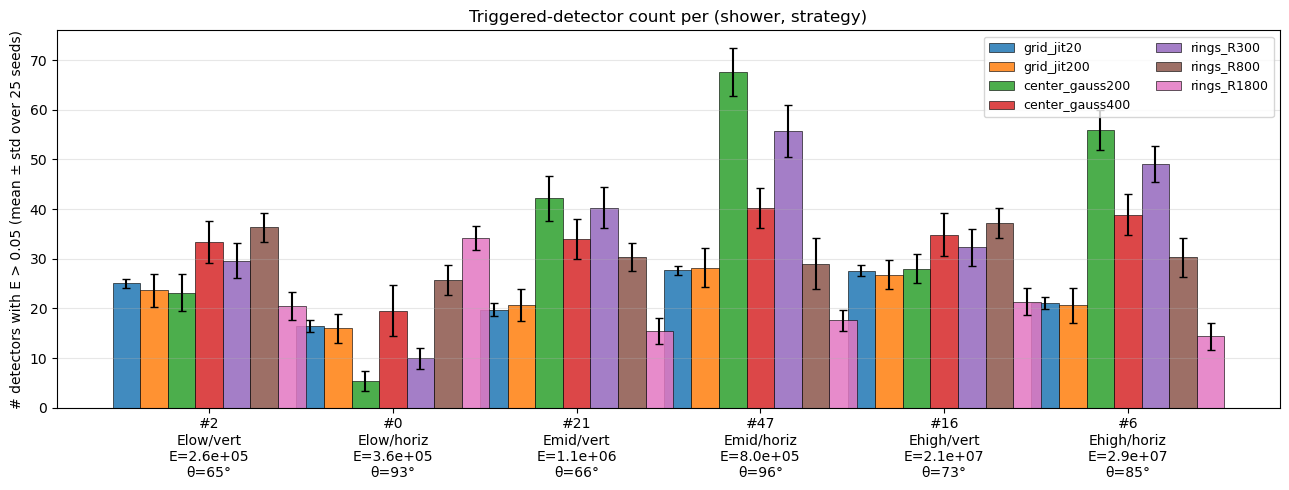

In [5]:
agg = df.groupby(['shower', 'tag', 'strategy'])['n_trig'].agg(['mean', 'std', 'min', 'max']).reset_index()

fig, ax = plt.subplots(1, 1, figsize=(13, 5))
showers = list(df_show['shower'])
tags = {int(r['shower']): r['tag'] for _, r in df_show.iterrows()}
strategy_names = [name for name, _, _ in _STRATEGIES]
n_str = len(strategy_names)
bar_w = 0.15
colors = plt.cm.tab10.colors[:n_str]

for i, s_name in enumerate(strategy_names):
    sub = agg[agg['strategy'] == s_name].set_index('shower').loc[showers]
    xs = np.arange(len(showers)) + (i - (n_str - 1) / 2.0) * bar_w
    ax.bar(xs, sub['mean'], width=bar_w, yerr=sub['std'], label=s_name,
           color=colors[i], capsize=3, alpha=0.85, edgecolor='black', linewidth=0.5)

ax.set_xticks(np.arange(len(showers)))
ax.set_xticklabels([f"#{s}\n{tags[s]}\nE={r['E']:.1e}\nθ={r['theta_deg']:.0f}°"
                    for s, (_, r) in zip(showers, df_show.iterrows())])
ax.set_ylabel('# detectors with E > 0.05 (mean ± std over 25 seeds)')
ax.set_title('Triggered-detector count per (shower, strategy)')
ax.legend(loc='upper right', ncol=2, fontsize=9)
ax.grid(alpha=0.3, axis='y')
fig.tight_layout(); plt.show()

## Detector patterns for representative (shower, layout) pairs

For each of the 6 showers, pick one strategy seed with mid-range trigger count and plot the layout colored by E. The grey background is the mountain centroids; small dots are detectors that received no signal; large warm dots are triggered detectors. The blue cloud overlays the shower's transverse particle cloud.

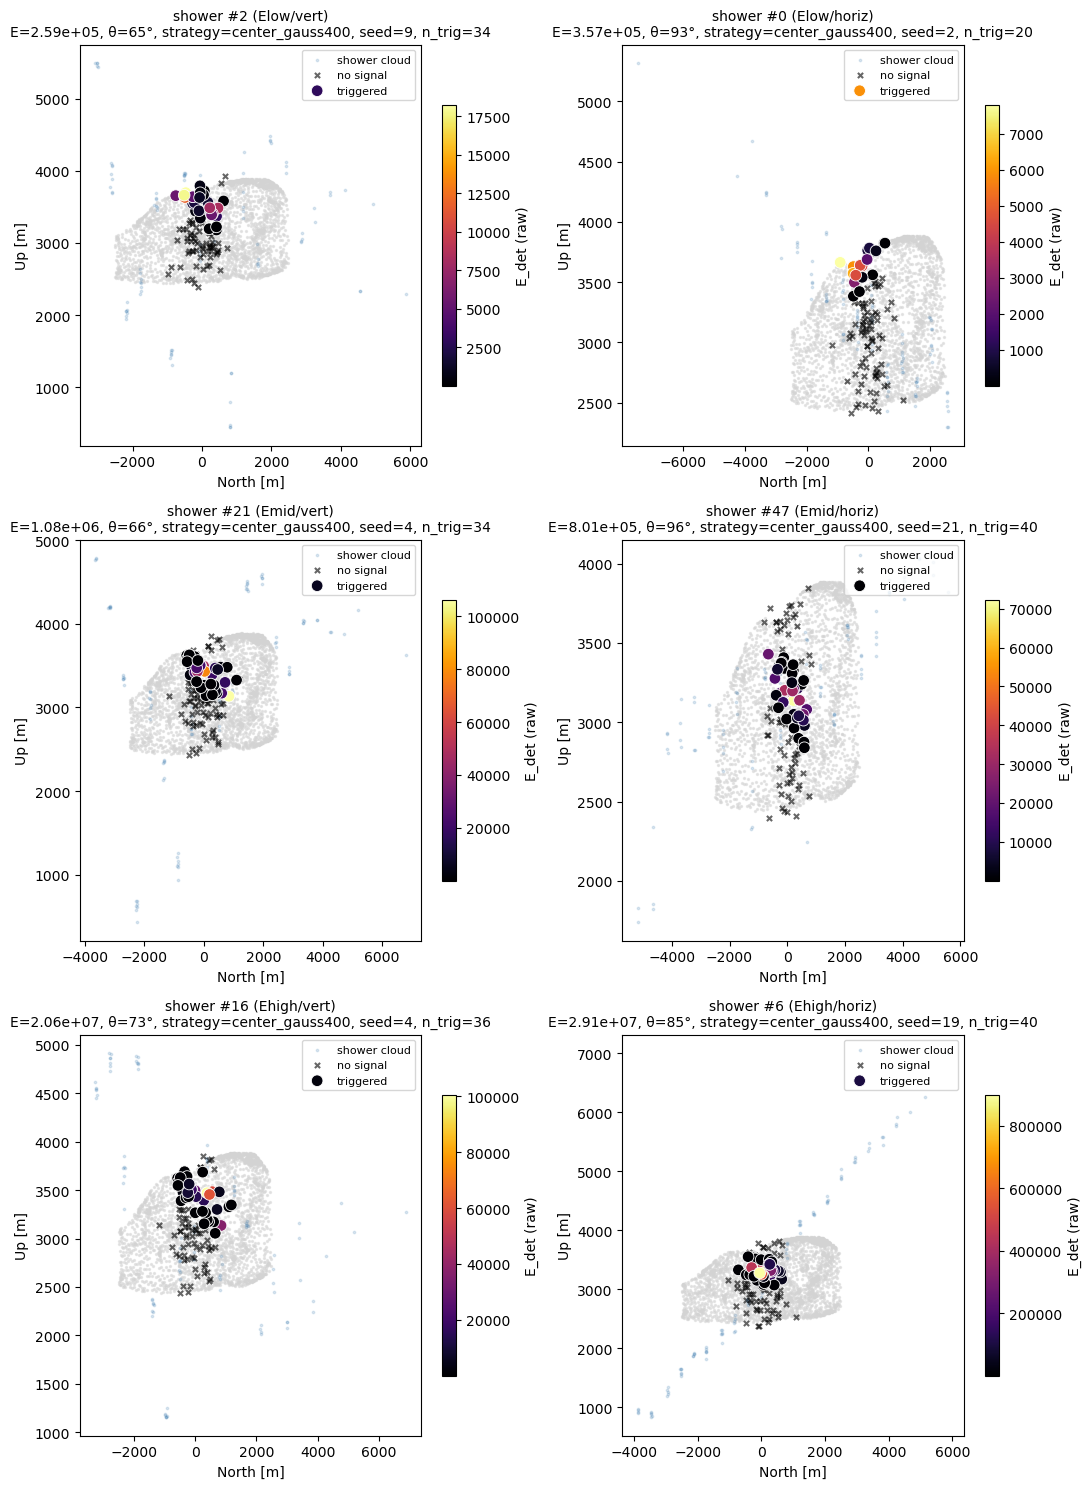

In [6]:
from matplotlib.colors import Normalize

# EXAMPLE_STRATEGY = 'rings_R300'  # the production-ish layout to look at
EXAMPLE_STRATEGY = 'center_gauss400' 
rows_per = 3; cols_per = (len(df_show) + rows_per - 1) // rows_per
fig, axes = plt.subplots(rows_per, cols_per, figsize=(5.5 * cols_per, 5 * rows_per), squeeze=False)

for ax, (_, row) in zip(axes.flat, df_show.iterrows()):
    s = int(row['shower'])
    # pick the seed whose trigger count is the median across the 25 seeds for this strategy
    seeds = df[(df['shower']==s) & (df['strategy']==EXAMPLE_STRATEGY)].sort_values('n_trig')
    pick_seed = int(seeds.iloc[len(seeds)//2]['seed'])
    E_arr, x_det, y_det = layouts_cache[(s, EXAMPLE_STRATEGY, pick_seed)]
    
    # Mountain centroids
    ax.scatter(mountain.centroids_NUE[:, 0], mountain.centroids_NUE[:, 1],
               s=2, c='lightgray', alpha=0.5)
    # Shower transverse cloud (downsampled)
    cloud = points[s].numpy()
    px, py = cloud[:, 0], cloud[:, 1]
    mask = (px != 0) | (py != 0)
    ax.scatter(px[mask][::20], py[mask][::20], s=3, c='steelblue', alpha=0.18,
               label=f'shower cloud')
    # Detectors
    triggered = E_arr > LAYOUT_THRESHOLD
    ax.scatter(x_det[~triggered], y_det[~triggered], s=14, c='black',
               marker='x', alpha=0.6, label='no signal')
    sc = ax.scatter(x_det[triggered], y_det[triggered],
                    c=E_arr[triggered], s=70, cmap='inferno',
                    edgecolor='white', linewidth=0.6, label='triggered')
    if triggered.any():
        plt.colorbar(sc, ax=ax, label='E_det (raw)', shrink=0.7)
    
    n_trig = int(triggered.sum())
    ax.set_aspect('equal')
    ax.set_title(f"shower #{s} ({row['tag']})\n"
                 f"E={row['E']:.2e}, θ={row['theta_deg']:.0f}°, "
                 f"strategy={EXAMPLE_STRATEGY}, seed={pick_seed}, n_trig={n_trig}",
                 fontsize=10)
    ax.set_xlabel('North [m]'); ax.set_ylabel('Up [m]')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_aspect('auto')

for ax in axes.flat[len(df_show):]:
    ax.set_visible(False)
fig.tight_layout(); plt.show()

## Same shower, different layout reinitializations

Pin one shower (highest mean trigger count) and one strategy, then show 6 different reinitializations side by side. This isolates the variance from layout randomness alone.

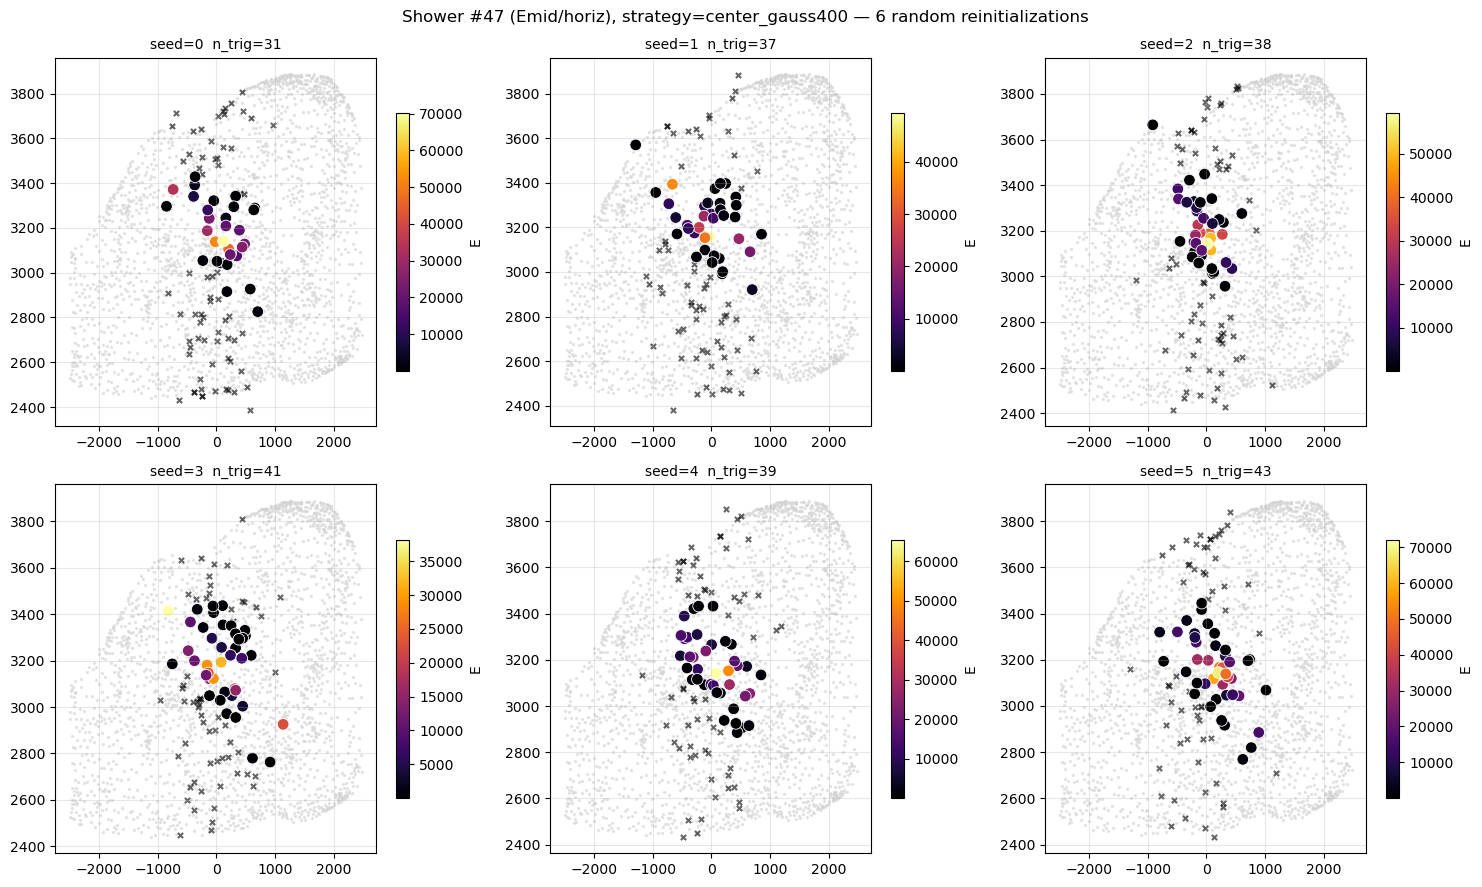

In [7]:
# pick the shower whose mean trigger count for EXAMPLE_STRATEGY is highest
best_row = (agg[agg['strategy']==EXAMPLE_STRATEGY].sort_values('mean', ascending=False).iloc[0])
s = int(best_row['shower'])
tag = tags[s]
n_show = 6
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, seed in zip(axes.flat, range(n_show)):
    E_arr, x_det, y_det = layouts_cache[(s, EXAMPLE_STRATEGY, seed)]
    ax.scatter(mountain.centroids_NUE[:, 0], mountain.centroids_NUE[:, 1],
               s=2, c='lightgray', alpha=0.5)
    triggered = E_arr > LAYOUT_THRESHOLD
    ax.scatter(x_det[~triggered], y_det[~triggered], s=14, c='black',
               marker='x', alpha=0.6)
    sc = ax.scatter(x_det[triggered], y_det[triggered],
                    c=E_arr[triggered], s=70, cmap='inferno',
                    edgecolor='white', linewidth=0.6)
    if triggered.any():
        plt.colorbar(sc, ax=ax, shrink=0.7, label='E')
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.set_title(f'seed={seed}  n_trig={int(triggered.sum())}', fontsize=10)
    ax.set_aspect('auto')
fig.suptitle(f"Shower #{s} ({tag}), strategy={EXAMPLE_STRATEGY} — 6 random reinitializations")
fig.tight_layout(); plt.show()

## Distribution of trigger counts across all (shower, layout) pairs sampled here

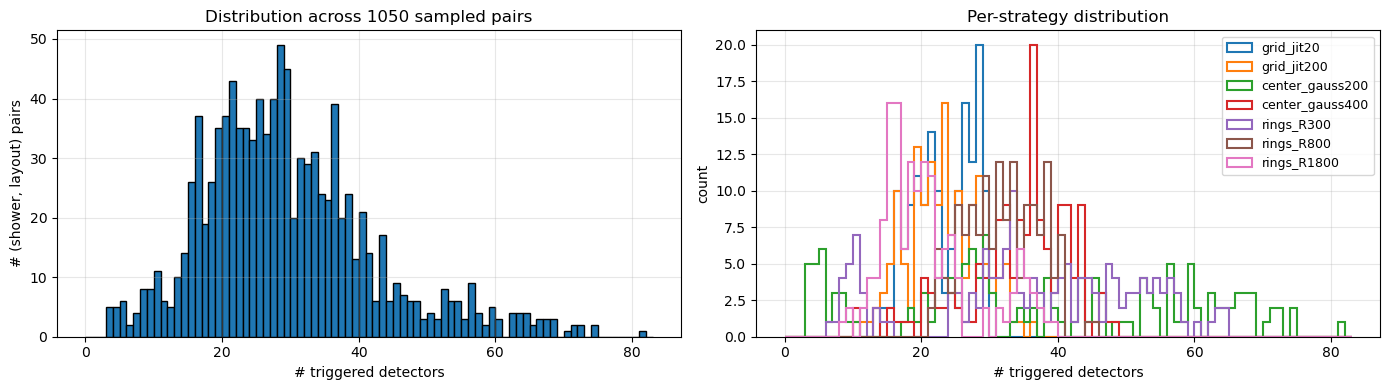

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['n_trig'], bins=range(0, df['n_trig'].max() + 3), edgecolor='black')
axes[0].set_xlabel('# triggered detectors'); axes[0].set_ylabel('# (shower, layout) pairs')
axes[0].set_title(f'Distribution across {len(df)} sampled pairs')
axes[0].grid(alpha=0.3)

for s_name in [n for n, _, _ in _STRATEGIES]:
    axes[1].hist(df[df['strategy']==s_name]['n_trig'], bins=range(0, df['n_trig'].max() + 3),
                 histtype='step', linewidth=1.5, label=s_name)
axes[1].set_xlabel('# triggered detectors'); axes[1].set_ylabel('count')
axes[1].set_title('Per-strategy distribution'); axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
fig.tight_layout(); plt.show()

## Summary table

In [9]:
summary = df.groupby(['tag', 'strategy'])['n_trig'].agg(['mean', 'std', 'min', 'max']).round(2)
summary

mean   std  min  max
tag         strategy                              
Ehigh/horiz center_gauss200  55.96  4.08   48   66
            center_gauss400  38.88  4.12   31   48
            grid_jit20       21.08  1.12   19   23
            grid_jit200      20.64  3.56   14   30
            rings_R1800      14.36  2.77    8   19
            rings_R300       49.08  3.55   43   55
            rings_R800       30.28  3.98   22   40
Ehigh/vert  center_gauss200  27.96  2.95   23   35
            center_gauss400  34.84  4.37   28   43
            grid_jit20       27.56  1.12   25   29
            grid_jit200      26.76  2.96   22   32
            rings_R1800      21.36  2.75   16   25
            rings_R300       32.28  3.71   25   40
            rings_R800       37.20  2.96   31   45
Elow/horiz  center_gauss200   5.40  2.06    3   10
            center_gauss400  19.56  5.08   10   32
            grid_jit20       16.40  1.15   14   18
            grid_jit200      15.96  2.89   10   23
            rings_R1800      34.16  2.49   29   39
            rings_R300        9.92  2.12    6   15
            rings_R800       25.68  2.95   21   33
Elow/vert   center_gauss200  23.16  3.70   17   30
            center_gauss400  33.36  4.17   25   40
            grid_jit20       25.04  0.89   23   26
            grid_jit200      23.64  3.34   19   31
            rings_R1800      20.44  2.81   14   25
            rings_R300       29.60  3.51   24   36
            rings_R800       36.36  2.93   29   44
Emid/horiz  center_gauss200  67.56  4.81   59   81
            center_gauss400  40.16  4.06   31   47
            grid_jit20       27.68  0.95   26   29
            grid_jit200      28.16  3.93   20   36
            rings_R1800      17.56  2.20   13   22
            rings_R300       55.68  5.27   44   64
            rings_R800       29.00  5.10   22   38
Emid/vert   center_gauss200  42.16  4.49   34   53
            center_gauss400  33.96  4.05   26   43
            grid_jit20       19.76  1.27   18   23
            grid_jit200      20.72  3.23   14   28
            rings_R1800      15.44  2.60   11   21
            rings_R300       40.28  4.15   32   49
            rings_R800       30.36  2.84   23   36